In [1]:
import pandas as pd

# Carrega os dados já tratados
df_brasil = pd.read_csv("../data/processed/cobertura_vacinal_brasil.csv")
df_gasto = pd.read_csv("../data/processed/gasto_saude_por_uf.csv")

# Cobertura nacional média por ano
cobertura_nacional = df_brasil.groupby("ano")["cobertura"].mean().reset_index()

# Gasto nacional médio por ano
gasto_nacional = df_gasto.groupby("ano")["gasto_saude_per_capita"].mean().reset_index()

# Reconstroi o índice de hesitação (mesmos números que já calculamos antes)
# Se df_trends ainda estiver em memória de outro notebook, pule esta parte
dados_hesitacao = {
    "ano": [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022],
    "interesse": [3.50, 4.92, 5.33, 8.17, 9.92, 12.92, 10.75, 12.67, 54.58, 30.58]
}
df_hesitacao = pd.DataFrame(dados_hesitacao)

# Junta tudo num único dataset
df_modelo = cobertura_nacional.merge(gasto_nacional, on="ano").merge(df_hesitacao, on="ano")

df_modelo

,ano,cobertura,gasto_saude_per_capita,interesse
0,2013,103.3600,422.684444,3.50
1,2014,103.0800,463.034444,4.92
2,2015,99.0850,485.099259,5.33
3,2016,91.2300,505.758148,8.17
4,2017,88.3525,530.658889,9.92
5,2018,92.6425,564.188148,12.92
6,2019,83.7300,583.788148,10.75
7,2020,78.2000,693.877407,12.67
8,2021,73.1350,836.801111,54.58
9,2022,81.3100,905.182593,30.58


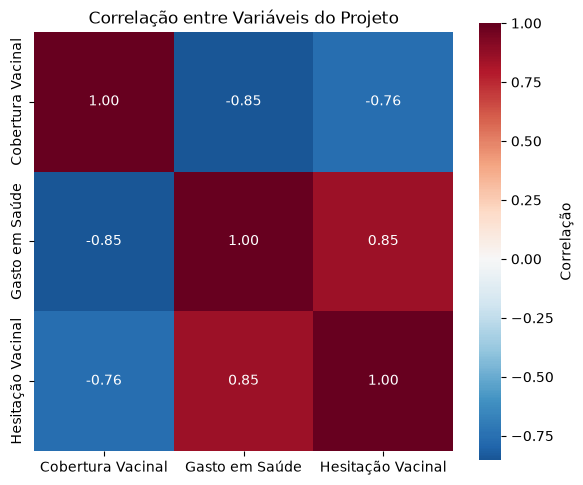

In [4]:
correlacoes = df_modelo[["cobertura", "gasto_saude_per_capita", "interesse"]].corr()

# Renomeia pra nomes mais legíveis no gráfico
correlacoes.columns = ["Cobertura Vacinal", "Gasto em Saúde", "Hesitação Vacinal"]
correlacoes.index = ["Cobertura Vacinal", "Gasto em Saúde", "Hesitação Vacinal"]

plt.figure(figsize=(6, 5))
sns.heatmap(correlacoes, annot=True, cmap="RdBu_r", center=0, fmt=".2f", square=True, cbar_kws={"label": "Correlação"})
plt.title("Correlação entre Variáveis do Projeto")
plt.tight_layout()
plt.savefig("../dashboard/mapa_calor_correlacoes.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
X = df_modelo[["gasto_saude_per_capita", "interesse"]]
y = df_modelo["cobertura"]

X = sm.add_constant(X)

modelo_simplificado = sm.OLS(y, X).fit()
print(modelo_simplificado.summary())

                            OLS Regression Results                            
Dep. Variable:              cobertura   R-squared:                       0.730
Model:                            OLS   Adj. R-squared:                  0.653
Method:                 Least Squares   F-statistic:                     9.459
Date:                Thu, 02 Jul 2026   Prob (F-statistic):             0.0102
Time:                        23:42:23   Log-Likelihood:                -30.561
No. Observations:                  10   AIC:                             67.12
Df Residuals:                       7   BIC:                             68.03
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    119